### 1. Setting Up OpenFace in Google Colab

In [1]:
!pip install -qq gdown
!gdown "https://drive.google.com/uc?id=1rVuzyC_A7NiD5YNWPA2SqGOLNPOWusiF" -O OpenFace_Portable.tar.gz
!tar -xzf OpenFace_Portable.tar.gz
!chmod +x /content/OpenFace/build/bin/FaceLandmarkVidMulti
!apt-get update -qq && apt-get install -y -qq ffmpeg libopencv-dev libboost-all-dev
!pip install rarfile


Downloading...
From (original): https://drive.google.com/uc?id=1rVuzyC_A7NiD5YNWPA2SqGOLNPOWusiF
From (redirected): https://drive.google.com/uc?id=1rVuzyC_A7NiD5YNWPA2SqGOLNPOWusiF&confirm=t&uuid=b00c7157-289c-460b-84e8-9c4b4e8d06f1
To: /content/OpenFace_Portable.tar.gz
100% 6.51G/6.51G [00:42<00:00, 152MB/s]
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Selecting previously unselected package libevdev2:amd64.
(Reading database ... 127332 files and directories currently installed.)
Preparing to unpack .../000-libevdev2_1.13.1+dfsg-1build1_amd64.deb ...
Unpacking libevdev2:amd64 (1.13.1+dfsg-1build1) ...
Selecting previously unselected package at-spi2-common.
Preparing to unpack .../001-at-spi2-common_2.52.0-1build1_all.deb ...
Unpacking at-spi2-common (2.52.0-1build1) ...
Selecting previously unselected p

In [2]:
# Find where the system OpenCV libraries are located to help us link the missing dependency
!find /usr/ -name "libopencv_highgui.so*"

/usr/lib/x86_64-linux-gnu/libopencv_highgui.so.4.6.0
/usr/lib/x86_64-linux-gnu/libopencv_highgui.so.406
/usr/lib/x86_64-linux-gnu/libopencv_highgui.so


In [3]:
# Create symbolic links to map the expected OpenCV 4.5d libraries to the installed 4.6.0 version
!ln -sf /usr/lib/x86_64-linux-gnu/libopencv_highgui.so.4.6.0 /usr/lib/x86_64-linux-gnu/libopencv_highgui.so.4.5d
!ln -sf /usr/lib/x86_64-linux-gnu/libopencv_objdetect.so.4.6.0 /usr/lib/x86_64-linux-gnu/libopencv_objdetect.so.4.5d
!ln -sf /usr/lib/x86_64-linux-gnu/libopencv_videoio.so.4.6.0 /usr/lib/x86_64-linux-gnu/libopencv_videoio.so.4.5d
!ln -sf /usr/lib/x86_64-linux-gnu/libopencv_imgcodecs.so.4.6.0 /usr/lib/x86_64-linux-gnu/libopencv_imgcodecs.so.4.5d
!ln -sf /usr/lib/x86_64-linux-gnu/libopencv_imgproc.so.4.6.0 /usr/lib/x86_64-linux-gnu/libopencv_imgproc.so.4.5d
!ln -sf /usr/lib/x86_64-linux-gnu/libopencv_core.so.4.6.0 /usr/lib/x86_64-linux-gnu/libopencv_core.so.4.5d

# Refresh the linker cache so the system finds the newly linked libraries
!ldconfig

/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero_v2.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb

### 2. Downloading and extracting the videos

In [4]:
import requests
import rarfile
from pathlib import Path

dataset_url = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"
base_dir = Path.cwd()

filename = Path(dataset_url).name
rar_path = base_dir / filename

# Downloading the dataset
with requests.get(dataset_url, stream=True, verify=False) as response:
   response.raise_for_status()
   with open(rar_path, 'wb') as file:
      for chunk in response.iter_content(chunk_size=8192):
         file.write(chunk)

# Extracting the dataset
with rarfile.RarFile(rar_path) as rf:
   rf.extractall(path=base_dir)

rar_path.unlink()

/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.crcv.ucf.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### 3. Running FaceLandmarkVidMulti on the "_c01" videos

In [5]:
import subprocess
import os

video_path = base_dir / "UCF-101"
output_dir = base_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)

videos = [f for f in video_path.rglob('*.avi') if "_c01" in f.name]

total_videos = len(videos)
print(f"Processing {total_videos} videos...\n\n")

# Configure the environment to use the pre-bundled libraries provided with OpenFace
env = os.environ.copy()
bundled_libs = "/content/OpenFace/bundled_libs"
env["LD_LIBRARY_PATH"] = f"{bundled_libs}:{env.get('LD_LIBRARY_PATH', '')}"

# Process each video in batches so we don't run out of memory
batch_size = 50
for i in range(0, total_videos, batch_size):
   batch = videos[i : i + batch_size]
   batch_num = (i // batch_size) + 1
   total_batches = (total_videos // batch_size) + 1
   print(f"Executing batch {batch_num} of {total_batches}...\n\n")

   openface_cmd = ["/content/OpenFace/build/bin/FaceLandmarkVidMulti"]

   for video in batch:
      openface_cmd.extend(["-f", str(video)])

   openface_cmd.extend(["-out_dir", str(output_dir)])

   process = subprocess.Popen(
      openface_cmd,
      stdout=subprocess.PIPE,
      stderr=subprocess.STDOUT,
      text=True,
      env=env
   )

   for line in process.stdout:
      print(line, end="")

   process.wait()

A streamkimeneten csak az utolsó 5000 sor látható.
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
40% Face too small for landmark detection
Face too small for landmark detection
50% 60% Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
70% Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
80% Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
Face too small for landmark detection
90% 100% 
Closing output recorder
Closing input reader


### 4. Calculating statistics

In [6]:
import pandas as pd
from pathlib import Path

csv_files = list(output_dir.rglob("*.csv"))

csv_stems = {f.stem for f in output_dir.rglob("*.csv")}
failed_videos = [v.stem for v in videos if v.stem not in csv_stems]

results = []

# Calculate statistics per video
for file_path in csv_files:
    df = pd.read_csv(file_path, skipinitialspace=True)

    if not df.empty:
        stats = (
            df.groupby("face_id", as_index=False)["confidence"]
            .mean()
            .rename(columns={"confidence": "mean_confidence"})
        )

        stats["video_name"] = file_path.stem

        number_of_faces = df["face_id"].nunique()
        stats["number_of_faces"] = number_of_faces

        results.append(stats)

    if df.empty or df["success"].sum() == 0:
        failed_videos.append(file_path.stem)


report = pd.concat(results, ignore_index=True)
report = report[["video_name", "face_id", "mean_confidence", "number_of_faces"]]
report.to_csv("/content/stats_per_video.csv", index=False)

successful_videos = [v.stem for v in videos if v.stem not in failed_videos]

failed_path = "/content/failed_videos.txt"

with open(failed_path, 'w') as f:
    f.write(f"Total of {len(failed_videos)} failed videos.\n\n")
    for video in failed_videos:
        f.write(f"{video}\n")

success_path = "/content/successful_videos.txt"

with open(success_path, 'w') as f:
    f.write(f"Total of {len(successful_videos)} successful videos.\n\n")
    for video in successful_videos:
        f.write(f"{video}\n")

Clips processed: 2525
Face tracked in: 323 (12.8%); failed: 2202
Mean landmark confidence per tracked face: median 0.13, IQR 0.02-0.66


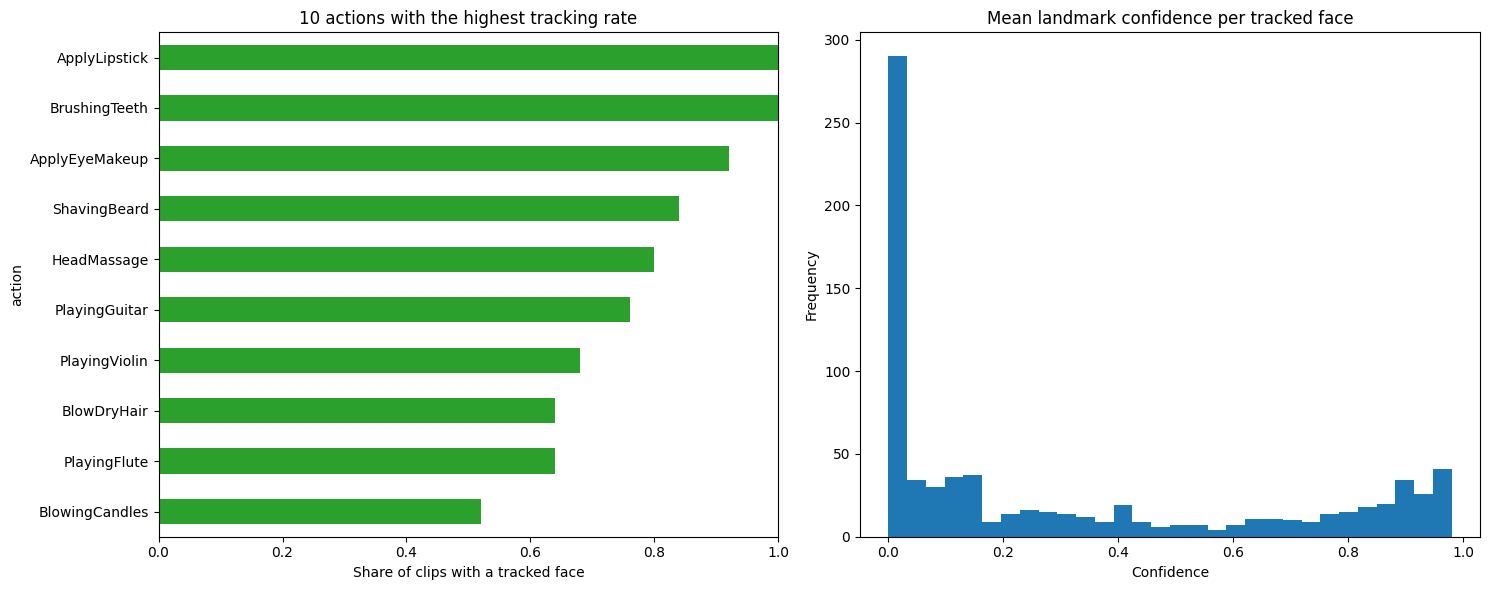

In [8]:
import matplotlib.pyplot as plt

status = pd.DataFrame({'video': [v.stem for v in videos]})
status['action'] = status['video'].str.split('_').str[1]
status['tracked'] = ~status['video'].isin(set(failed_videos))

n_total, n_ok = len(status), int(status['tracked'].sum())
print(f"Clips processed: {n_total}")
print(f"Face tracked in: {n_ok} ({n_ok / n_total:.1%}); failed: {n_total - n_ok}")
print(f"Mean landmark confidence per tracked face: median {report['mean_confidence'].median():.2f}, "
      f"IQR {report['mean_confidence'].quantile(0.25):.2f}-{report['mean_confidence'].quantile(0.75):.2f}")

per_action = status.groupby('action')['tracked'].mean().sort_values()

# Created 2 subplots instead of 3 to exclude the lowest tracking rate plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot the top 10 actions with the highest tracking rate
per_action.tail(10).plot.barh(ax=axes[0], color='tab:green', title='10 actions with the highest tracking rate')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Share of clips with a tracked face')

# Plot the mean landmark confidence distribution
report['mean_confidence'].plot.hist(bins=30, ax=axes[1], title='Mean landmark confidence per tracked face')
axes[1].set_xlabel('Confidence')

plt.tight_layout()
plt.show()